# 2D Inversion

These are the steps to generate a 2D inversion from data collected at SAGE.

1. Load data
2. Extract a profile
3. Check strike direction
4. Interpolate onto same period map
5. Check data/edit
6. Setup inversion mesh
7. Run inversion
8. Check data fits
9. Change parameters and run again.


In [1]:
## Be sure to run this cell to enable Panel in VS Code
import panel as pn
pn.extension(comms='vscode')

## 1. Load data

We created an H5 file earlier with all the data.  We will load that into an `MTData` object so we can extract a profile.  

**NOTE**: Be sure to change the .h5 file path to your local path.

In [2]:
from mtpy import MTCollection

In [3]:
with MTCollection() as mc:
    mc.open_collection(r"c:\Users\jpeacock\OneDrive - DOI\SAGE\sage_2026.h5")
    md = mc.to_mt_data()
    md.utm_epsg = 32613 # set the UTM zone for the data

26:06:27T20:53:42 | INFO | line:1035 |mth5.mth5 | close_mth5 | Flushing and closing c:\Users\jpeacock\OneDrive - DOI\SAGE\sage_2026.h5


### Plot Station to get profile

Plot the station map to identify how you want to orient the profile.


In [4]:
station_plot = md.plot_stations()
station_plot.panel().servable()

BokehModel(combine_events=True, render_bundle={'docs_json': {'9741595f-0f91-4d3e-b982-486f404054a8': {'version…

The dominant strike is roughly NS, so profile lines should be roughly EW.

## 2. Extract Profile
From the map pick your profile lines.

In [5]:
end_point_01 = {"latitude": 35.95, "longitude": -106.2}
end_point_02 = {"latitude": 35.95, "longitude": -106.7}

In [6]:
# the syntax is (lon1, lat1, lon2, lat2, distance from profile in meters)
profile = md.get_profile(end_point_01["longitude"], end_point_01["latitude"], end_point_02["longitude"], end_point_02["latitude"], 1000)

In [7]:
profile

MTData(stations=11, surveys=7, lazy_stations=0, metadata_storage='cache', dataset_copy_mode='shallow', index_enabled=False)

In [8]:
profile_map = profile.plot_stations()
profile_map.panel().servable()

BokehModel(combine_events=True, render_bundle={'docs_json': {'ab5bbe0a-baf2-4ef4-bda5-0851f3c35f32': {'version…

## 3. Check Strike Direction

We want the profile to be roughly perpendicular to strike.

In [9]:
profile_strike = profile.plot_strike()
profile_strike.panel().servable()

BokehModel(combine_events=True, render_bundle={'docs_json': {'643e43a9-bc4c-499a-84fe-f1b4823c0d64': {'version…

## 4. Edit the data

To edit the data you'll unfortunately have to clone another package.  To do that follow these instructions.

1. Clone the `mtpy-gui` repository: `git clone https://github.com/MTgeophysics/mtpy-gui.git` to a directory of your chosing.  
2. In your environment run
    - `conda install pyqt=5`
    - Change directory into the `mtpy-gui` repository
    - `pip install -e .`
3. From your conda environment while in the `mtpy-gui` environment run `python .\mtpy_gui\modeling\mt_editor_qt5.py`

Hopefully, a window will pop-up for you to load in some data and edit it. 

Do the following for editing:

1. Write the profile transfer functions to EDI files and save them in a folder of your choice
2. In the GUI load one station at a time and edit, then save to a new EDI file
3. Load the edited files back into an `MTData` object.


In [10]:
# 1. write transfer functions to EDI files

from pathlib import Path
save_path = Path(r"c:\Users\jpeacock\OneDrive - DOI\SAGE\profile_2026")
save_path.mkdir(exist_ok=True)

for station in profile.station_paths:
    mo = profile.get_station(station, as_mt=True)
    mo.write(save_path / f"{mo.station}.edi")

In [11]:
# 3. Load the edited EDI files back in
from mtpy import MTData

edited_profile = MTData()
loaded_files = edited_profile.add_station(list(save_path.joinpath("edited").glob("*.edi")))
edited_profile.utm_epsg = 32613
edited_profile = edited_profile.get_profile(end_point_01["longitude"], end_point_01["latitude"], end_point_02["longitude"], end_point_02["latitude"], 1000)


## 5. Interpolate

We want the data to be uniform in that the transfer functions are mapped onto the same periods.  We will do that through interpolation. Then we will check the data quality so that we are trying to fit noise.

We want to interpolate over a range of periods and provide the inversion with enough data to constrain the model. But not so much that inversion is inefficient.  Play around with the period range and the number of periods


In [12]:
plot_responses = edited_profile.plot_mt_responses()
plot_responses.panel().servable()

BokehModel(combine_events=True, render_bundle={'docs_json': {'d41062de-c23f-47ec-8b63-4f595451a513': {'version…

In [13]:
import numpy as np

In [14]:
# we need the data to have the same periods for the inversion, so we will interpolate the data to a common set of periods
interp_periods = np.logspace(np.log10(0.03), np.log10(500), 32)

In [15]:
edited_profile.interpolate(interp_periods)

In [16]:
profile_responses = edited_profile.plot_mt_responses()
profile_responses.panel().servable()

BokehModel(combine_events=True, render_bundle={'docs_json': {'e31f02f2-c25b-45be-906a-6a66e14472fa': {'version…

## 6. Set up Simpeg 2D data

Here we will provide an example of inverting the data in 2D using `simpeg`.  We will invert the east-west profile line.  In this case we are lucky in that the profile line is perpendicular to the conductive block, if the profile line was not perpendicular then rotations of the data and locations would need to be done.  This is where 2D becomes very complicated.  As we saw above the strike angle can change with location and period, so which strike angle do you use for the 2D inversion.  Much of the '90s-'00s were spent on clever methods to deal with changing geoelectrical strike, such as rotating the impedance tensor per period to maximize the right-hand components ($xy$ and $yx$) and minimize the parallel components ($xx$ and $yy$), or remove 3D responses, etc.  Most of this clever analysis is taken care of in 3D inversion. However, the compute time is much less than compared to 3D so model testing is much faster.  If you invert your data in 2D beware of all the caveats that come with estimating a 2D model from innately 3D data. 

In [17]:
from mtpy.modeling.simpeg.recipes import Simpeg2D

#### Estimate starting half-space

Starting from a half-space close to the data is usually a good idea as it provides the inversion a good starting point.

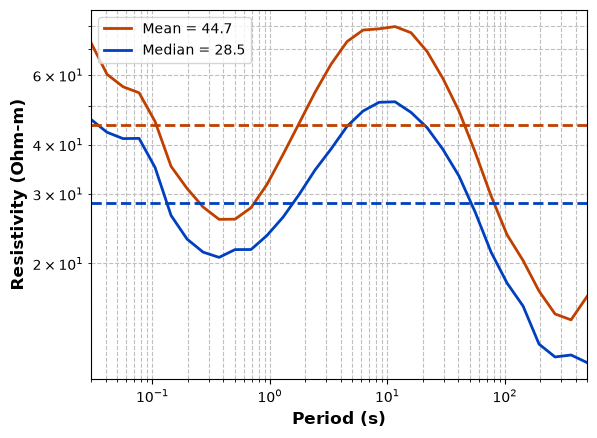

In [18]:
edited_profile.estimate_starting_rho()

### Create 2D Dataframe
Create a dataframe to input into the inversion.  A few key things with `simpeg` is that the units for inversion are in $\Omega$, and we need to sort the stations by the profile distance.

In [19]:
data_2d = edited_profile.to_dataframe(impedance_units="ohm")
data_2d = data_2d.sort_values(by=["profile_offset"])

# need to set the resistivity and phase model error floors, 1.5 degrees in phase and 5 Ohm-m in apparent resistivity.
data_2d["phase_yx_model_error"] = 1.5
data_2d["phase_xy_model_error"] = 1.5
data_2d["res_yx_model_error"] = 5.0
data_2d["res_xy_model_error"] = 5.0

Create the `Simpeg2D` object from which we can manipulate control parameters.

You want to make sure that there are at least 4 cells between stations, and the model is large enough to remove edge effects.


  TensorMesh: 16,434 cells

                      MESH EXTENT             CELL WIDTH      FACTOR
  dir    nC        min           max         min       max      max
  ---   ---  ---------------------------  ------------------  ------
   x     99   -259,514.97    273,176.97    198.00 86,702.99    1.50
   y    166 -2,268,774.87        870.37     44.00 108,078.80    1.50




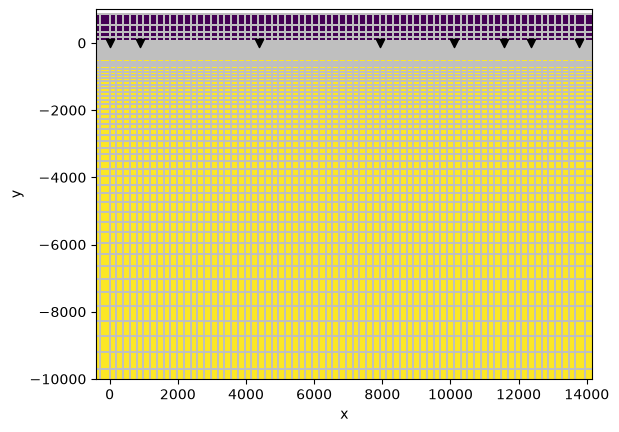

In [30]:
simpeg_2d = Simpeg2D(
    data_2d,
    mesh_kwargs={
        "sigma_background": 1.0 / 100,
        "z_factor_max": 20,
        "z_geometric_factor_down": 1.05,
        "x_spacing_factor": 4.0
    },
    data_kwargs={"invert_impedance": False, "include_elevation": False},
    max_iterations=10,                     # maximum number of iterations
    alpha_s=1e-4,                          # smallness multiplication factor (smaller more smooth model) 
    alpha_y=1,                             # smallness multiplication factor in y-direction (horizontal smoothing)          
    alpha_z=1,                             # smallness multiplication factor in z-direction (vertical smoothing)
    use_irls=False,                        # if p_s, p_y, p_z are not 2, then using IRLs (iteratively re-weighted least-squares) should be used  
    p_s=2,                                 # smallness norm 2: L2-norm, 1: L1-norm, 0: blocky model
    p_y=2,                                 # norm in the y-direction 2: L2-norm, 1: L1-norm, 0: blocky model
    p_z=2,                                 # norm in the z-direction 2: L2-norm, 1: L1-norm, 0: blocky model
)
print(simpeg_2d.mesh.mesh)

### Plot Data

Just want to make sure that the input data is what is expected.  Plot all stations for the two right hand modes $xy$ and $yx$. 

In [31]:
simpeg_2d.data.dataframe[["res_xy", "res_xy_model_error", "phase_xy", "phase_xy_model_error", "res_yx", "res_yx_model_error", "phase_yx", "phase_yx_model_error"]]

,res_xy,res_xy_model_error,phase_xy,phase_xy_model_error,res_yx,res_yx_model_error,phase_yx,phase_yx_model_error
0,16.825595,5.0,55.169321,1.5,9.709889,5.0,-121.824531,1.5
1,15.921953,5.0,56.193718,1.5,8.253195,5.0,-121.315747,1.5
2,15.191150,5.0,55.940522,1.5,7.471801,5.0,-121.857872,1.5
3,13.676153,5.0,56.592544,1.5,6.413969,5.0,-120.602863,1.5
4,10.808601,5.0,59.258203,1.5,5.115039,5.0,-120.404438,1.5
...,...,...,...,...,...,...,...,...
251,26.045255,5.0,59.601307,1.5,10.469338,5.0,-107.381932,1.5
252,22.884439,5.0,56.383489,1.5,5.661533,5.0,-106.060664,1.5
253,20.442370,5.0,51.027401,1.5,2.839771,5.0,-109.621873,1.5
254,20.969106,5.0,46.895586,1.5,2.196970,5.0,-123.550777,1.5


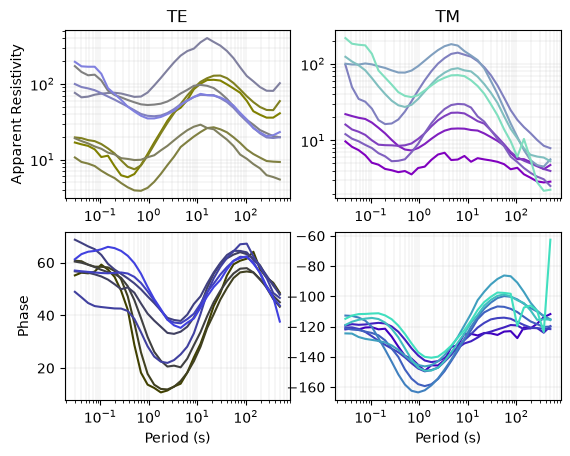

In [32]:
simpeg_2d.data.plot_response()

### Run 2D inversion
Now, run the inversion plotting the resulting model, Tikhanov curve, and data versus model response.  For the most part this simple setup fits the data well, but changing some of the parameters could produce a better model. 

The response plot is a little odd, here we are plotting all stations for all periods, so the first station is the first 14 data points in each plot

Be sure that `pydiso` is installed.  If it isnt' run `conda install mkl-devel pydiso -c conda-forge`

In [33]:
%%time
inversion_output = simpeg_2d.run_inversion()


INFO: 
simpeg.InvProblem is setting bfgsH0 to the inverse of the reg.deriv2
using the same solver as the Simulation2DMagneticField simulation with the 'is_symmetric=True` option set.




Running inversion with SimPEG v0.25.2
============================ Inexact Gauss Newton ============================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS    Comment   
-----------------------------------------------------------------------------
   0  8.96e-03  1.84e+05  0.00e+00  1.84e+05                                 
   1  8.96e-03  1.02e+05  1.88e+03  1.02e+05    2.86e+04      0              
   2  4.48e-03  7.72e+04  6.80e+04  7.76e+04    3.18e+03      1   Skip BFGS  
   3  2.24e-03  6.58e+04  6.71e+04  6.60e+04    1.28e+04      0              
   4  1.12e-03  6.14e+04  9.02e+04  6.15e+04    1.91e+03      3   Skip BFGS  
   5  5.60e-04  5.78e+04  1.16e+05  5.79e+04    2.11e+03      3   Skip BFGS  
   6  2.80e-04  5.56e+04  1.45e+05  5.57e+04    2.57e+03      3              
   7  1.40e-04  5.42e+04  1.71e+05  5.42e+04    4.07e+03      3              
   8  7.00e-05  5.15e+04  2.27e+05  5.15e+04    6.96e+03      2              
   9  3.50e-05  5.13e+04

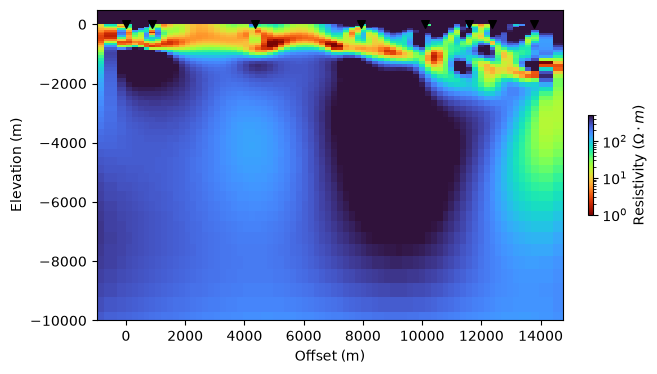

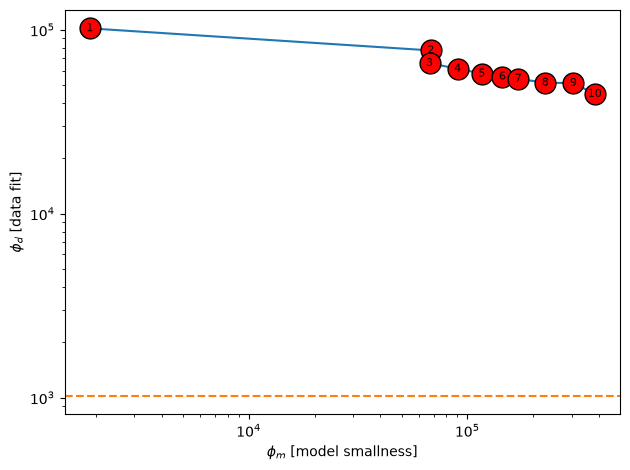

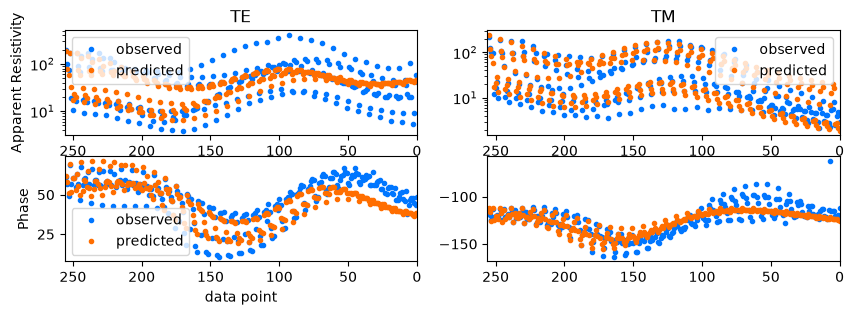

In [34]:
simpeg_2d.plot_iteration(10, z_limits=(-10000, 500), vmin=1, vmax=500)
simpeg_2d.plot_tikhonov_curve()
simpeg_2d.plot_responses(10)

### Run with a tree mesh

We can try to run on a tree mesh, it might be faster.


QuadTreeMesh: 0.11% filled

Level : Number of cells               Mesh Extent               Cell Widths    
-----------------------           min     ,     max            min   ,   max   
  2   :        4             ---------------------------   --------------------
  3   :       36          x: -251644.1694638431,251644.1694638431   245.74625924203428, 125822.08473192155
  4   :       36          y:   -225280.0  ,  225280.0        220.0   ,  112640.0 
  5   :       32       
  6   :       40       
  7   :       40       
  8   :       66       
  9   :       132      
 10   :      1248      
 11   :      3008      
-----------------------
Total :      4642      


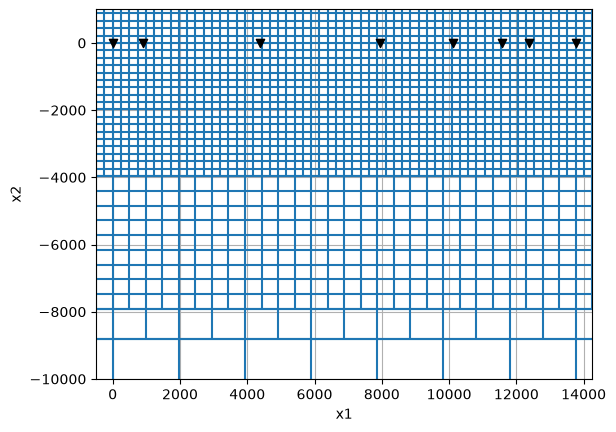

In [43]:
simpeg_2d_tree = Simpeg2D(
    data_2d,
    mesh_type="tree",
    mesh_kwargs={
        "sigma_background": 1.0 / 100,
        "z_factor_max": 20,
        "z_geometric_factor_down": 1.05,
        "factor_spacing": 8.0,
        "station_padding": [16, 8],
    },
    data_kwargs={"invert_impedance": False, "include_elevation": False},
    max_iterations=10,                     # maximum number of iterations
    alpha_s=1e-4,                          # smallness multiplication factor (smaller more smooth model) 
    alpha_y=1,                             # smallness multiplication factor in y-direction (horizontal smoothing)          
    alpha_z=1,                             # smallness multiplication factor in z-direction (vertical smoothing)
    use_irls=False,                        # if p_s, p_y, p_z are not 2, then using IRLs (iteratively re-weighted least-squares) should be used  
    p_s=2,                                 # smallness norm 2: L2-norm, 1: L1-norm, 0: blocky model
    p_y=2,                                 # norm in the y-direction 2: L2-norm, 1: L1-norm, 0: blocky model
    p_z=2,                                 # norm in the z-direction 2: L2-norm, 1: L1-norm, 0: blocky model
)
print(simpeg_2d_tree.mesh.mesh)

In [ ]:
%%time
inversion_output_tree = simpeg_2d_tree.run_inversion()

INFO: 
simpeg.InvProblem is setting bfgsH0 to the inverse of the reg.deriv2
using the same solver as the Simulation2DMagneticField simulation with the 'is_symmetric=True` option set.




Running inversion with SimPEG v0.25.2
============================ Inexact Gauss Newton ============================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS    Comment   
-----------------------------------------------------------------------------
   0  1.18e-02  1.85e+05  0.00e+00  1.85e+05                                 
   1  1.18e-02  9.40e+04  9.40e+04  9.52e+04    5.46e+04      0              
   2  5.90e-03  8.55e+04  1.15e+05  8.62e+04    8.49e+03      3   Skip BFGS  
   3  2.95e-03  7.98e+04  1.40e+05  8.02e+04    9.98e+03      3   Skip BFGS  
